In [1]:
import pandas as pd

# Direct link to a hosted version of the Rossmann dataset
url = "https://github.com/hahdawg/gbmclass/raw/master/rossmann.csv"
df = pd.read_csv(url, low_memory=False)

# Convert date column to datetime objects
print(df.head())


   store  dayofweek        date  sales  open  promo stateholiday  \
0     25          5  2015-07-31  14180     1      1            0   
1     25          4  2015-07-30  11272     1      1            0   
2     25          3  2015-07-29  10527     1      1            0   
3     25          2  2015-07-28  10865     1      1            0   
4     25          1  2015-07-27  11806     1      1            0   

   schoolholiday  
0              1  
1              1  
2              1  
3              1  
4              1  


In [3]:
df1=pd.DataFrame(df).copy()
df1.isnull().sum()

,0
store,0
dayofweek,0
date,0
sales,0
open,0
promo,0
stateholiday,0
schoolholiday,0


In [4]:
df1['date']=pd.to_datetime(df1['date'])
df1.describe()

,store,dayofweek,date,sales,open,promo,schoolholiday
count,93832.000000,93832.000000,93832,93832.000000,93832.000000,93832.000000,93832.000000
mean,559.896581,3.997932,2014-04-15 20:16:51.646346496,10258.218284,0.843412,0.382087,0.182656
min,25.000000,1.000000,2013-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000
25%,336.000000,2.000000,2013-08-23 00:00:00,8031.750000,1.000000,0.000000,0.000000
50%,532.000000,4.000000,2014-04-15 00:00:00,10518.000000,1.000000,0.000000,0.000000
75%,756.000000,6.000000,2014-12-08 00:00:00,13558.000000,1.000000,1.000000,0.000000
max,1114.000000,7.000000,2015-07-31 00:00:00,38722.000000,1.000000,1.000000,1.000000
std,287.646337,1.997359,NaN,5781.824608,0.363414,0.485900,0.386386


In [5]:
print(df1['open'].value_counts(normalize=True))

df1['year'] = df1['date'].dt.year
df1['month'] = df1['date'].dt.month
df1['day_of_week'] = df1['date'].dt.dayofweek


#we have 15% of data as store is marked closed

open
1    0.843412
0    0.156588
Name: proportion, dtype: float64


In [6]:
df1[df1['sales']!=0]


,store,dayofweek,date,sales,open,promo,stateholiday,schoolholiday,year,month,day_of_week
0,25,5,2015-07-31,14180,1,1,0,1,2015,7,4
1,25,4,2015-07-30,11272,1,1,0,1,2015,7,3
2,25,3,2015-07-29,10527,1,1,0,1,2015,7,2
3,25,2,2015-07-28,10865,1,1,0,1,2015,7,1
4,25,1,2015-07-27,11806,1,1,0,1,2015,7,0
...,...,...,...,...,...,...,...,...,...,...,...
93825,1114,1,2013-01-07,21237,1,1,0,0,2013,1,0
93827,1114,6,2013-01-05,18856,1,0,0,0,2013,1,5
93828,1114,5,2013-01-04,18371,1,0,0,1,2013,1,4
93829,1114,4,2013-01-03,18463,1,0,0,1,2013,1,3


<Axes: xlabel='year', ylabel='avg_sales_per_store_yr'>

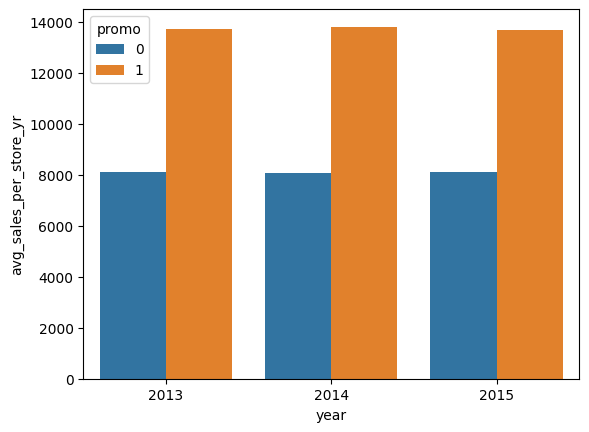

In [7]:
import seaborn as sns
avg_sales_per_store_promo=df1.groupby(['year','month','store','promo']).agg(avg_sales_per_store=('sales','mean')).reset_index()

# with promo/non promo avg sales per store yearly

yearly_avg_sales=avg_sales_per_store_promo.groupby(['year','promo']).agg(avg_sales_per_store_yr=('avg_sales_per_store','mean')).reset_index()

#sns.lineplot(data=yearly_avg_sales, x='year', y='avg_sales_per_store_yr', hue='promo')

sns.barplot(data=yearly_avg_sales, x='year', y='avg_sales_per_store_yr', hue='promo')

# avg sales per store is quite higher where promo is applied{lets check if the promo is applied everyday or just on weekend}.


<Axes: xlabel='sales', ylabel='Density'>

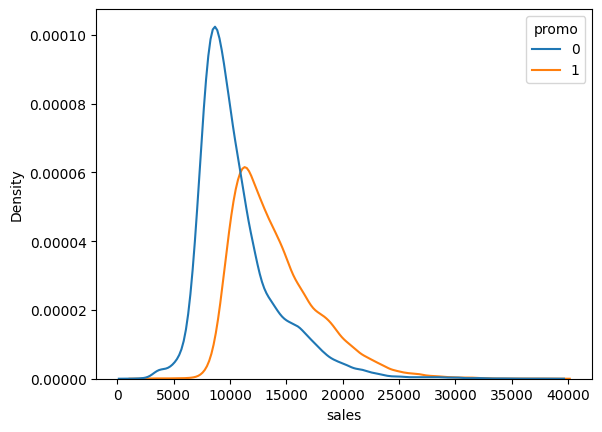

In [8]:
import seaborn as sns

sns.kdeplot(data=df1[df1['sales']!=0], x='sales', hue='promo')

In [9]:
from scipy import stats
import pandas as pd

# 1. Define your two independent groups
# Example: Sales during Promo vs Sales during No-Promo
group_a = df1[df1['promo'] == 1]['sales']
group_b = df1[df1['promo'] == 0]['sales']

# 2. Perform the Independent T-Test
# 'equal_var=False' is safer for real-world business data (Welch's T-Test)
t_stat, p_val = stats.ttest_ind(group_a, group_b, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

T-statistic: 172.9171
P-value: 0.0000


<Axes: xlabel='year', ylabel='avg_promo'>

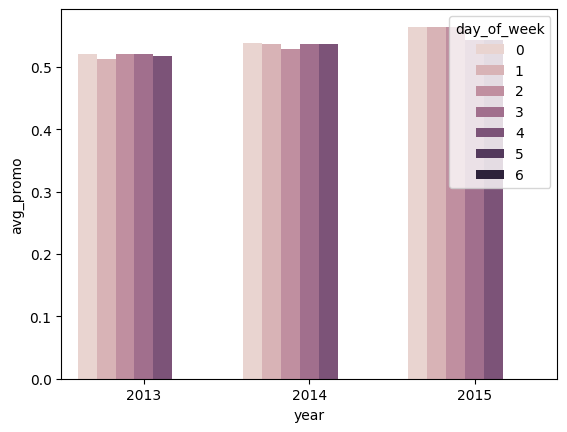

In [10]:
# day basis avg store promo is applied


day_promo_code=df1.groupby(['year','month','store','day_of_week']).agg(avg_promo_code=('promo','mean')).reset_index()

yearly_avg_sales=day_promo_code.groupby(['year','day_of_week']).agg(avg_promo=('avg_promo_code','mean'))
sns.barplot(data=yearly_avg_sales, x='year', y='avg_promo', hue='day_of_week')


#its not like the promo is being applied to only on weekends or weekdays

# with promo/non promo avg sales per store yearly

#print(avg_sales_per_store_promo.groupby(['month','promo']).agg(avg_sales_per_store_yr=('avg_sales_per_store','mean')).reset_index())


<Axes: xlabel='month', ylabel='avg_promo'>

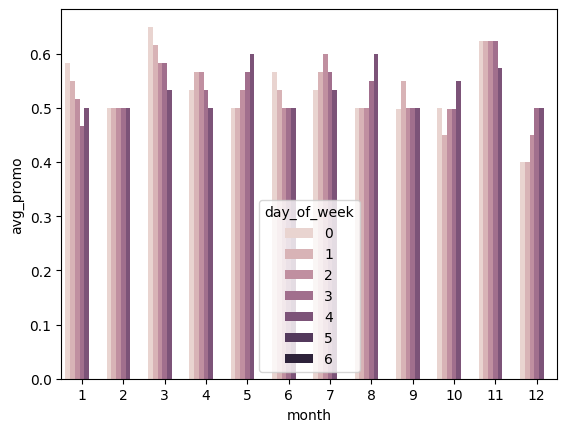

In [11]:
yearly_avg_sales=day_promo_code.groupby(['month','day_of_week']).agg(avg_promo=('avg_promo_code','mean'))
sns.barplot(data=yearly_avg_sales, x='month', y='avg_promo', hue='day_of_week')


<Axes: xlabel='month', ylabel='total_sales'>

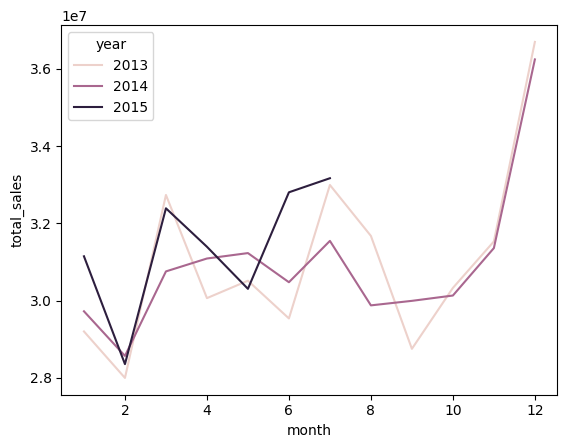

In [12]:
yearly_sales=df1.groupby(['year','month']).agg(total_sales=('sales','sum')).reset_index()
sns.lineplot(data=yearly_sales, x='month', y='total_sales', hue='year')


# we see a seasonal trend, the sales spikes during the time of december(possibly due to christmas and new year)

<Axes: xlabel='year', ylabel='avg_sales_per_store_yr'>

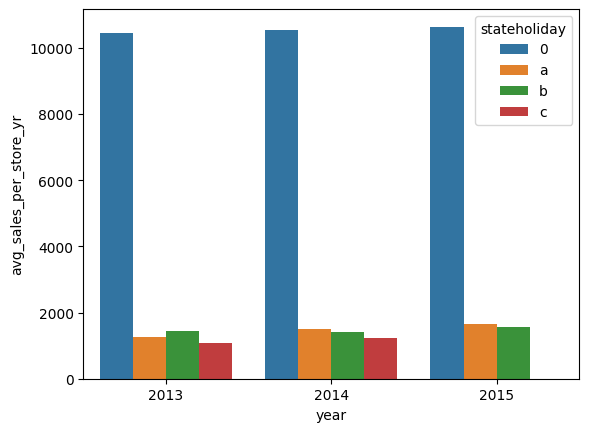

In [13]:
avg_sales_per_store_state=df1.groupby(['year','month','store','stateholiday']).agg(avg_sales_per_store=('sales','mean')).reset_index()


yearly_avg_sales_state_holiday=avg_sales_per_store_state.groupby(['year','stateholiday']).agg(avg_sales_per_store_yr=('avg_sales_per_store','mean')).reset_index()

#sns.lineplot(data=yearly_avg_sales, x='year', y='avg_sales_per_store_yr', hue='promo')

sns.barplot(data=yearly_avg_sales_state_holiday, x='year', y='avg_sales_per_store_yr', hue='stateholiday')


#state holiday sees a dip in sales per store

<Axes: xlabel='year', ylabel='avg_sales_per_store_yr'>

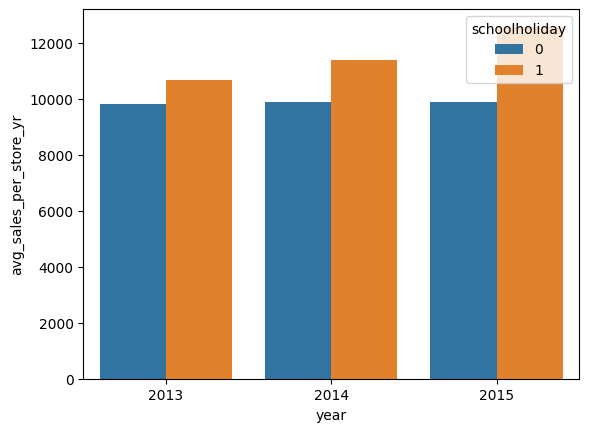

In [14]:
avg_sales_per_store_state=df1.groupby(['year','month','store','schoolholiday']).agg(avg_sales_per_store=('sales','mean')).reset_index()


yearly_avg_sales_school_holiday=avg_sales_per_store_state.groupby(['year','schoolholiday']).agg(avg_sales_per_store_yr=('avg_sales_per_store','mean')).reset_index()

#sns.lineplot(data=yearly_avg_sales, x='year', y='avg_sales_per_store_yr', hue='promo')

sns.barplot(data=yearly_avg_sales_school_holiday, x='year', y='avg_sales_per_store_yr', hue='schoolholiday')


In [15]:
df1[['stateholiday','open']].value_counts().reset_index()

df1.groupby(['stateholiday','open']).agg(stores=('stateholiday','count'))
# 'value_counts' is singular, and 'normalize' must be lowercase
#86% of stores open when there in no state holiday, wehreas during stateholiday the no of store opens drops to 10%

stores
stateholiday open        
0            0      12264
             1      78874
a            0       1523
             1        175
b            0        546
             1         54
c            0        360
             1         36

In [16]:

df1=df1[(df1['open'] == 1) & (df1['sales'] > 0)]

df1['is_state_holiday']  = (df1['stateholiday'] != '0').astype(int)
df1['is_school_holiday'] = df1['schoolholiday'].astype(int)

In [79]:
from sklearn.metrics import mean_squared_error , mean_absolute_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error

def accuract_mtrycs(x, y):
    n=[]
    # print(f'MAPE: {mean_absolute_percentage_error(x, y):.4f}')
    # print(f'MAE:  {mean_absolute_error(x, y):.4f}')
    # print(f'RMSE: {root_mean_squared_error(x, y):.4f}')
    # print(f'R2:   {r2_score(x, y):.4f}')
    n.extend([
    mean_absolute_percentage_error(x, y),
    mean_absolute_error(x, y),
    root_mean_squared_error(x, y),
    r2_score(x, y)])
    print(n)
    return(n)
    #n.insert(0,n)
    #new_row = pd.DataFrame(n, columns=pf.columns)
    #pf = pd.concat([pf, new_row], ignore_index=True)




    # print(n.extend([mean_absolute_percentage_error(x, y),
    #                  mean_absolute_error(x, y),
    #                  root_mean_squared_error(x, y),
    #                  r2_score(x, y)
    #                  ]))

In [90]:
pf = pd.DataFrame(columns=['Store', 'MAPE', 'MAE', 'RMSE', 'R2'])

store=list(df['store'].sort_values().unique())
for i in range(len(store)):
    # 1. Prepare store-specific data

    sd = df1[df1['store'] == store[i]].sort_values('date').reset_index(drop=True)
    sd['ds'] = pd.to_datetime(sd['date'])
    sd['y']  = sd['sales']

    # 2. Create holiday dataframe for this store
    hol_dates = sd[sd['is_state_holiday'] == 1][['ds']].copy()
    hol_dates['holiday']      = 'state_holiday'
    hol_dates['lower_window'] = -1
    hol_dates['upper_window'] = 0

    # 3. Initialize Model
    prophet = Prophet(
        holidays           = hol_dates,
        yearly_seasonality = True,
        weekly_seasonality = True,
        daily_seasonality  = False,
        seasonality_mode   = 'additive',
        interval_width     = 0.90
    )

    # 4. Add Regressors (Fixed Indentation)
    prophet.add_regressor('promo')
    prophet.add_regressor('is_school_holiday')

    # 5. Fit the model
    # Note: Using double brackets [[ ]] for selection
    prophet.fit(sd[['ds', 'y', 'promo', 'is_school_holiday']])

    # 6. Predict only for this store's timeframe
    # This ensures prophet_forecast['yhat'] matches sd['y'] length
    prophet_forecast = prophet.predict(sd[['ds', 'promo', 'is_school_holiday']])

    # 7. Calculate Metrics
    print(f"--- Results for Store {i} ---")
    pp=accuract_mtrycs(sd['y'], prophet_forecast['yhat'])
    pp.insert(0,store[i])
    pf.loc[len(pf)]=pp
    #concat list to pf



--- Results for Store 0 ---
[0.12703415751927105, 1286.43804686119, 1904.4382769611618, 0.5393629293347572]
--- Results for Store 1 ---
[0.11303116292620807, 1081.9907005959144, 1499.7664634806702, 0.7494879202653262]
--- Results for Store 2 ---
[0.09546040597456636, 975.6156855163522, 1342.3251342033734, 0.7083894179987458]
--- Results for Store 3 ---
[0.13317196090830194, 1411.2872956771214, 2109.1347535737054, 0.6724742758186438]
--- Results for Store 4 ---
[0.10356550732881208, 1056.6460185413105, 1433.2952177506238, 0.705758721656867]
--- Results for Store 5 ---
[0.09511934023334441, 1220.737982638428, 1667.3890963460026, 0.6796396832616698]
--- Results for Store 6 ---
[0.05926273133697964, 602.0796860022227, 810.8541057661731, 0.6726560506860102]
--- Results for Store 7 ---
[0.10093299886904798, 1157.0761323457684, 1607.8027664588399, 0.6556847580378617]
--- Results for Store 8 ---
[0.09705703863303437, 909.9906226959395, 1263.9086628495872, 0.7280111297230509]
--- Results for St

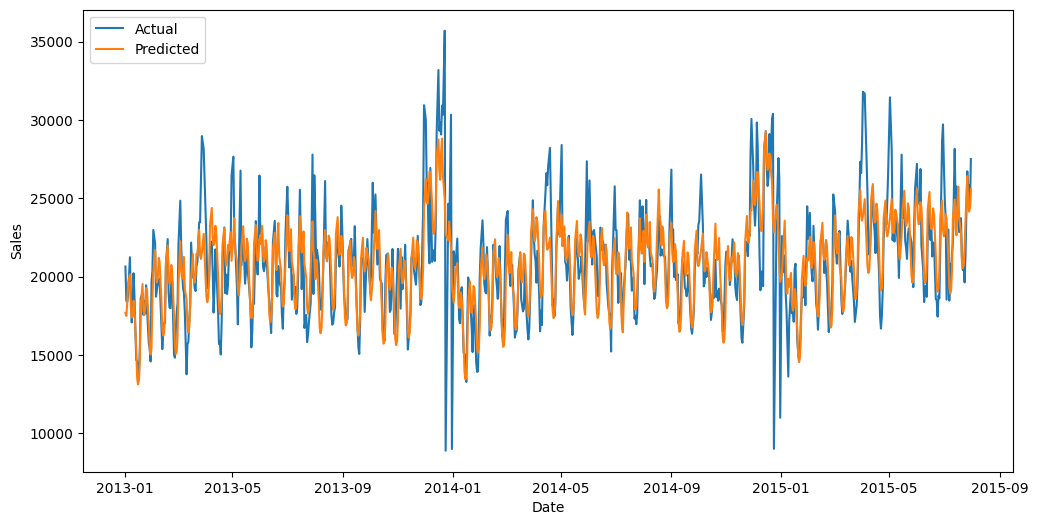

In [94]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(sd['ds'], sd['y'], label='Actual')
plt.plot(sd['ds'], prophet_forecast['yhat'], label='Predicted')
plt.legend(loc='upper left')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

99

In [87]:
pf

,Store,MAPE,MAE,RMSE,R2
0,1,2,3,4,5


In [67]:
pf=pd.DataFrame( columns=['Store', 'MAPE', 'MAE', 'RMSE', 'R2'])

In [69]:
pf=pd.DataFrame( columns=['Store', 'MAPE', 'MAE', 'RMSE', 'R2'])
pd.concat([pf,[1,2,3,4,5] ], ignore_index=True)

TypeError: cannot concatenate object of type '<class 'list'>'; only Series and DataFrame objs are valid

In [20]:
df1.head(5)

,store,dayofweek,date,sales,open,promo,stateholiday,schoolholiday,year,month,day_of_week,is_state_holiday,is_school_holiday
0,25,5,2015-07-31,14180,1,1,0,1,2015,7,4,0,1
1,25,4,2015-07-30,11272,1,1,0,1,2015,7,3,0,1
2,25,3,2015-07-29,10527,1,1,0,1,2015,7,2,0,1
3,25,2,2015-07-28,10865,1,1,0,1,2015,7,1,0,1
4,25,1,2015-07-27,11806,1,1,0,1,2015,7,0,0,1
